# 03 — Temporal Dynamics

Temporal structure of the Jane Street responders, focusing on the competition target
`responder_6`:

- **Responder autocorrelation by lag** within a single liquid symbol, in chronological order.
- **Per-day responder volatility** (std per `date_id`) for all nine responders.
- **Intraday seasonality** of `responder_6` across `time_id`.
- **Regime shifts** across `date_id` via rolling statistics of daily volatility.

Tabular artifacts are written to `results/dataset/`, figures to `results/figures/`.

In [1]:
from pathlib import Path

import numpy as np
import polars as pl

import matplotlib.pyplot as plt

from IPython.display import display

from loguru import logger

PROJECT_ROOT = Path.cwd().parents[0]

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "jane"

TRAIN_DIR = DATA_ROOT / "train.parquet"

OUTPUT_DIR = PROJECT_ROOT / "results" / "dataset"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pl.scan_parquet(TRAIN_DIR / "**" / "*.parquet")

responder_cols = [f"responder_{i}" for i in range(9)]

logger.info("Scanning train data from {}", TRAIN_DIR)

2026-07-28 16:20:54.580 | INFO     | __main__:<module>:28 - Scanning train data from D:\distribution-free-sequential-learning\data\raw\jane\train.parquet


lag,acf
i64,f64
1,0.88524
2,0.828866
3,0.777716
4,0.728666
5,0.680932
6,0.634567
7,0.588343
8,0.54265
9,0.497256


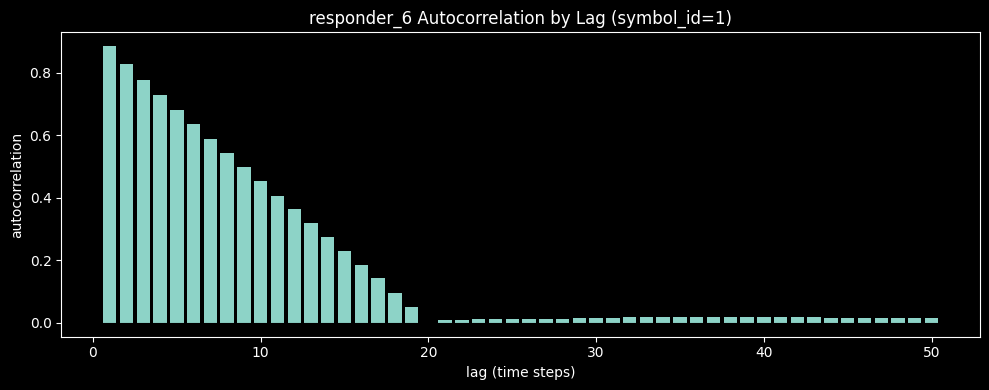

In [2]:
# Autocorrelation of responder_6 by lag for one liquid symbol (chronological order).
series = (
    train
    .filter(pl.col("symbol_id") == 1)
    .sort("date_id", "time_id")
    .select("responder_6")
    .collect()["responder_6"]
    .to_numpy()
    .astype(np.float64)
)

max_lag = 50
mean = series.mean()
var = ((series - mean) ** 2).mean()

acf = [
    float(((series[:-lag] - mean) * (series[lag:] - mean)).mean() / var)
    for lag in range(1, max_lag + 1)
]

acf_df = pl.DataFrame({"lag": list(range(1, max_lag + 1)), "acf": acf})

display(acf_df.head(10))

acf_df.write_csv(OUTPUT_DIR / "responder6_autocorrelation.csv")

plt.figure(figsize=(10, 4))

plt.bar(acf_df["lag"].to_numpy(), acf_df["acf"].to_numpy())

plt.axhline(0.0, color="black", linewidth=0.8)

plt.title("responder_6 Autocorrelation by Lag (symbol_id=1)")
plt.xlabel("lag (time steps)")
plt.ylabel("autocorrelation")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "responder6_autocorrelation.png", dpi=300)

plt.show()

date_id,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8
i16,f32,f32,f32,f32,f32,f32,f32,f32,f32
0,0.884881,0.948112,0.728587,1.123619,0.8659,1.173627,0.529894,0.471536,0.590221
1,1.139215,1.588193,0.975548,1.497635,1.286414,1.451624,0.812211,0.680455,0.862557
2,1.083671,1.353648,0.919947,1.255573,1.460485,1.071219,0.797652,0.939326,0.807152
3,1.190394,1.449388,1.062176,1.263838,1.296475,1.187293,0.968893,0.948256,0.965366
4,1.007228,1.527432,0.833051,1.152847,0.862705,1.256367,0.698249,0.585874,0.764447


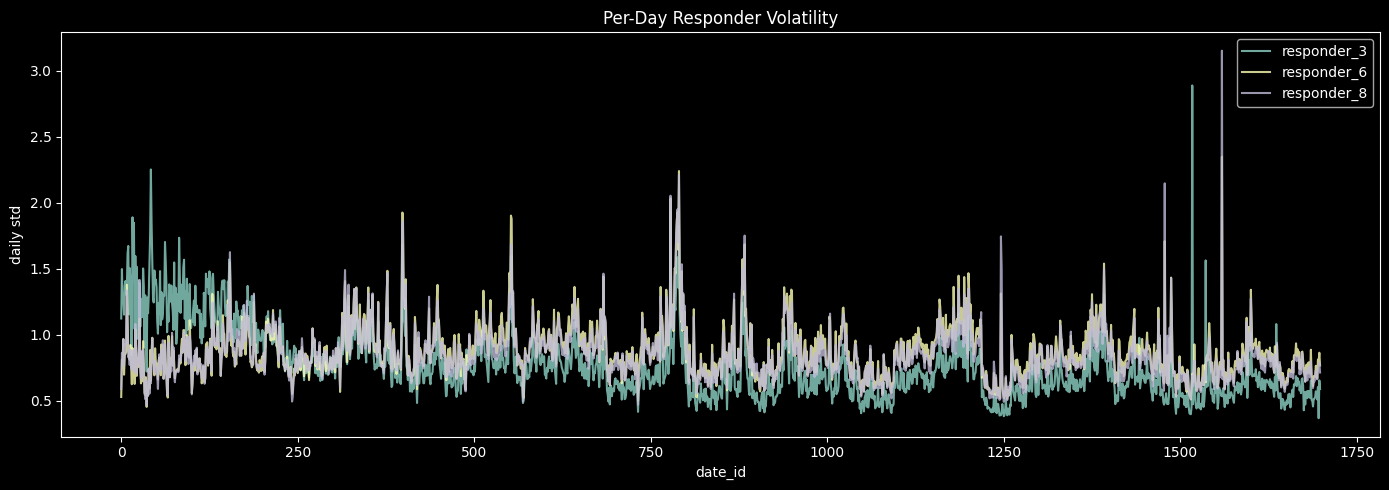

In [3]:
# Per-day volatility (std) of every responder.
daily_vol = (
    train
    .group_by("date_id")
    .agg([pl.col(c).std().alias(c) for c in responder_cols])
    .sort("date_id")
    .collect()
)

display(daily_vol.head())

daily_vol.write_csv(OUTPUT_DIR / "daily_responder_volatility.csv")

plt.figure(figsize=(14, 5))

for c in ["responder_3", "responder_6", "responder_8"]:
    plt.plot(
        daily_vol["date_id"].to_numpy(),
        daily_vol[c].to_numpy(),
        label=c,
        alpha=0.8,
    )

plt.title("Per-Day Responder Volatility")
plt.xlabel("date_id")
plt.ylabel("daily std")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "daily_responder_volatility.png", dpi=300)

plt.show()

time_id,mean,mean_abs,std
i16,f32,f32,f32
0,0.052467,1.352035,1.83252
1,0.06795,1.322525,1.799635
2,0.079768,1.298869,1.769385
3,0.075213,1.280586,1.752766
4,0.078779,1.260442,1.725714


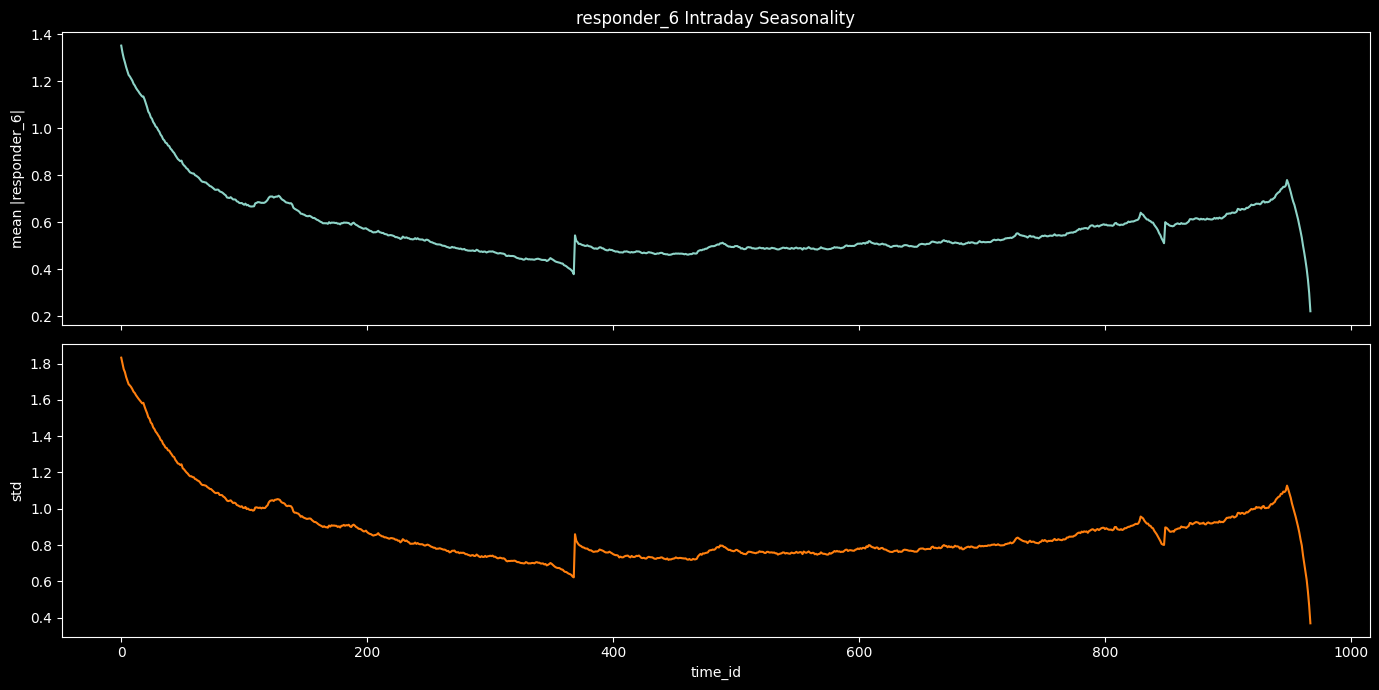

In [4]:
# Intraday (time_id) seasonality of responder_6.
intraday = (
    train
    .group_by("time_id")
    .agg(
        pl.col("responder_6").mean().alias("mean"),
        pl.col("responder_6").abs().mean().alias("mean_abs"),
        pl.col("responder_6").std().alias("std"),
    )
    .sort("time_id")
    .collect()
)

display(intraday.head())

intraday.write_csv(OUTPUT_DIR / "responder6_intraday.csv")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(intraday["time_id"].to_numpy(), intraday["mean_abs"].to_numpy())
axes[0].set_title("responder_6 Intraday Seasonality")
axes[0].set_ylabel("mean |responder_6|")

axes[1].plot(
    intraday["time_id"].to_numpy(),
    intraday["std"].to_numpy(),
    color="tab:orange",
)
axes[1].set_xlabel("time_id")
axes[1].set_ylabel("std")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "responder6_intraday.png", dpi=300)

plt.show()

date_id,responder_6,rolling_mean,rolling_std,shift_score
i16,f32,f32,f32,f32
0,0.529894,null,null,null
1,0.812211,null,null,null
2,0.797652,null,null,null
3,0.968893,null,null,null
4,0.698249,null,null,null
5,0.84534,null,null,null
6,0.854173,null,null,null
7,0.870583,null,null,null
8,1.379004,null,null,null


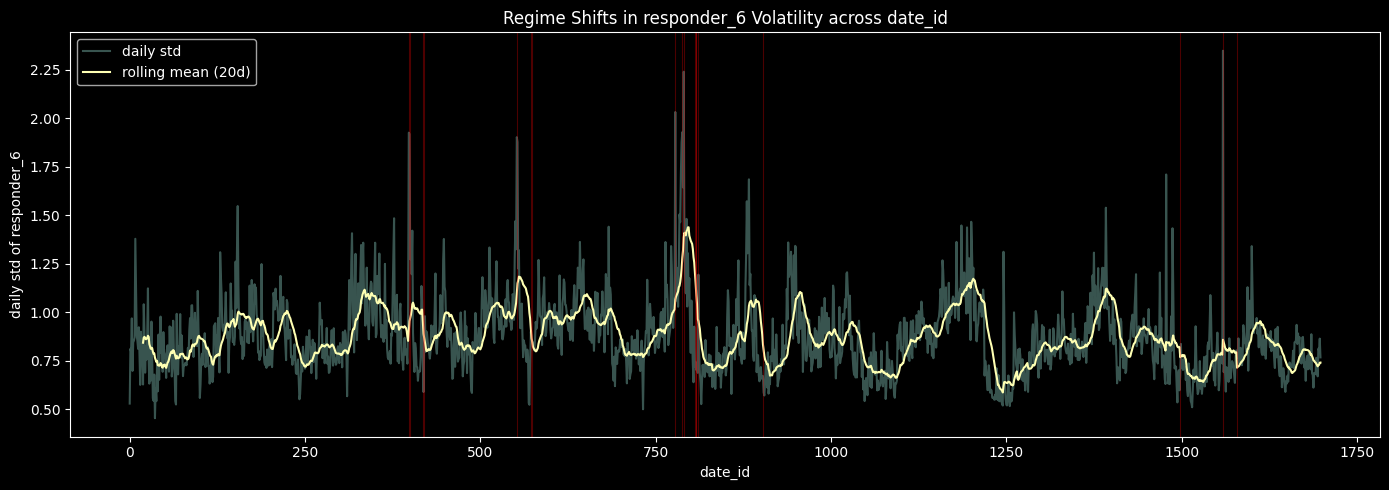

In [5]:
# Regime shifts across date_id: rolling statistics of daily responder_6 volatility.
window = 20

regime = (
    daily_vol
    .select("date_id", "responder_6")
    .with_columns(
        pl.col("responder_6").rolling_mean(window_size=window).alias("rolling_mean"),
        pl.col("responder_6").rolling_std(window_size=window).alias("rolling_std"),
    )
    .with_columns(
        pl.col("rolling_mean").diff().abs().alias("shift_score")
    )
)

display(regime.sort("shift_score", descending=True).head(10))

regime.write_csv(OUTPUT_DIR / "responder6_regimes.csv")

threshold = regime["shift_score"].quantile(0.99)
shift_days = regime.filter(pl.col("shift_score") >= threshold)["date_id"].to_list()

plt.figure(figsize=(14, 5))

plt.plot(
    regime["date_id"].to_numpy(),
    regime["responder_6"].to_numpy(),
    alpha=0.4,
    label="daily std",
)

plt.plot(
    regime["date_id"].to_numpy(),
    regime["rolling_mean"].to_numpy(),
    label=f"rolling mean ({window}d)",
)

for d in shift_days:
    plt.axvline(d, color="red", alpha=0.3, linewidth=0.8)

plt.title("Regime Shifts in responder_6 Volatility across date_id")
plt.xlabel("date_id")
plt.ylabel("daily std of responder_6")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "responder6_regime_shifts.png", dpi=300)

plt.show()

2026-07-28 16:21:01.827 | INFO     | __main__:<module>:12 - Tracking distributional drift of: ['feature_47', 'feature_21', 'feature_31']


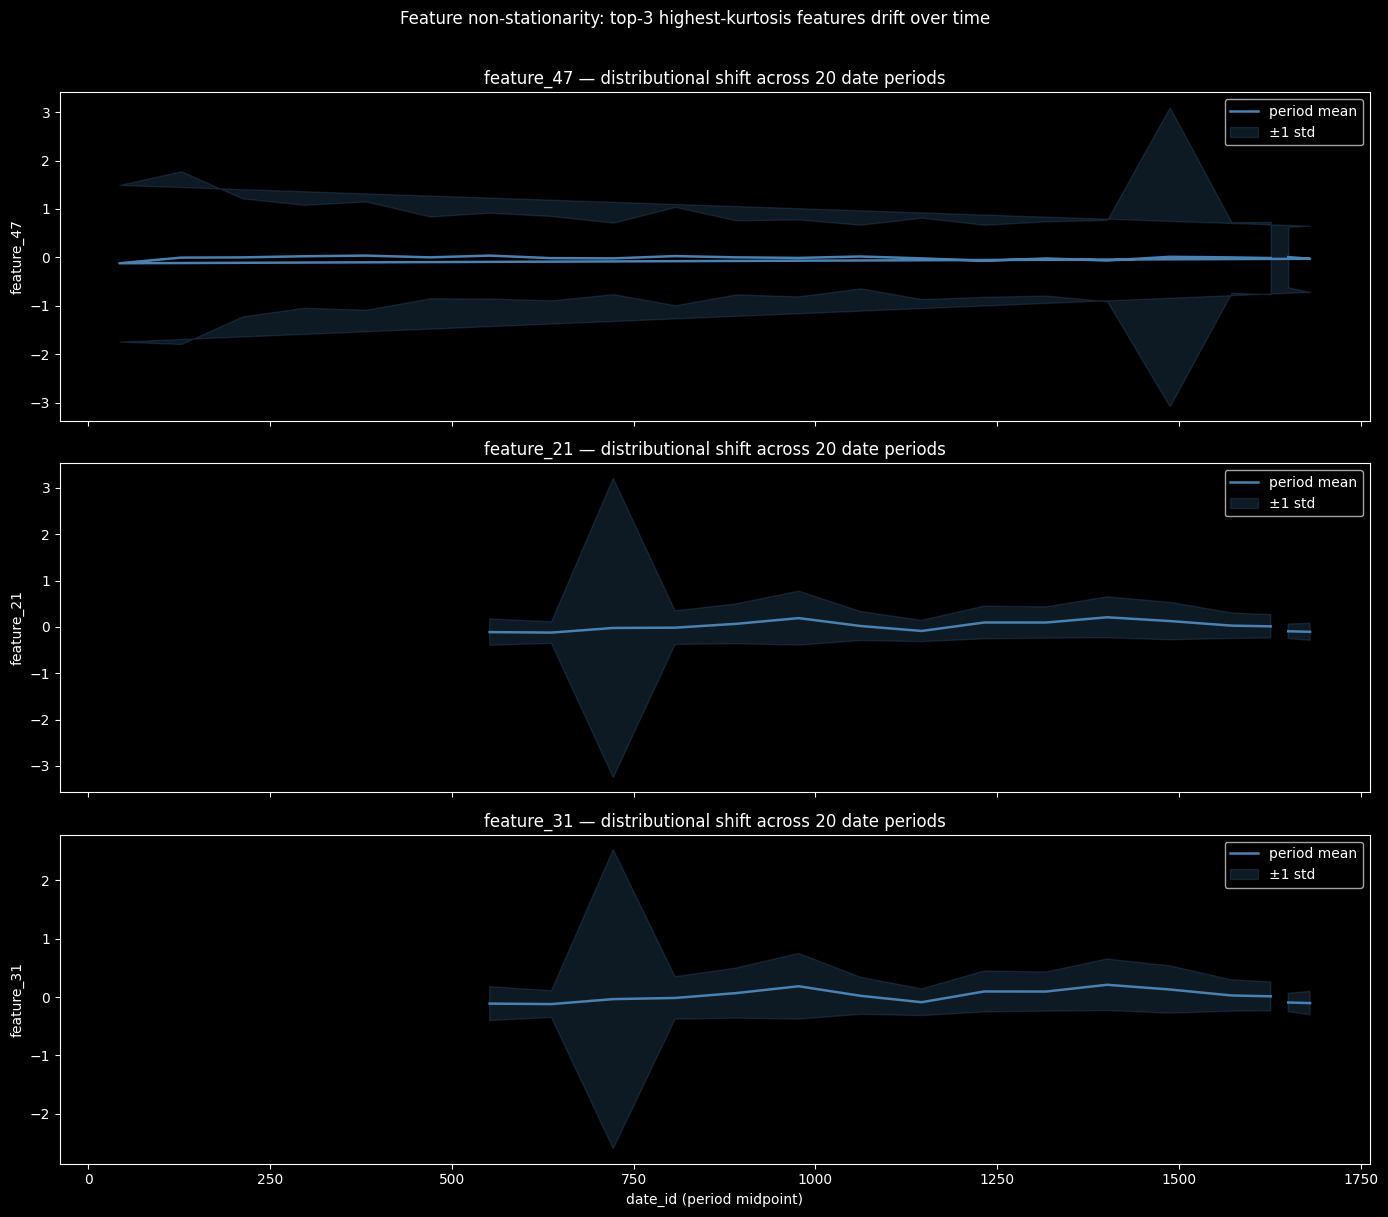

In [6]:
# --- Feature Non-stationarity: Distribution Drift over Time ---
# Online learners must handle distributional shift without re-fitting.
# Here we show that the top-3 highest-kurtosis features' means and spreads
# drift substantially across 20 date periods — motivating adaptive over
# fixed-window methods.

kurtosis_csv = OUTPUT_DIR / "feature_kurtosis.csv"
if kurtosis_csv.exists():
    drift_features = pl.read_csv(kurtosis_csv).head(3)["feature"].to_list()
else:
    drift_features = ["feature_13", "feature_12", "feature_14"]
logger.info(f"Tracking distributional drift of: {drift_features}")

n_periods = 20
drift_df = (
    train
    .with_columns(
        ((pl.col("date_id") * n_periods) // 1699).cast(pl.Int32).alias("period")
    )
    .group_by("period")
    .agg([
        pl.col("date_id").mean().cast(pl.Int32).alias("date_mid"),
        *[pl.col(c).mean().alias(f"{c}_mean") for c in drift_features],
        *[pl.col(c).std().alias(f"{c}_std")  for c in drift_features],
    ])
    .sort("period")
    .collect()
)
drift_df.write_csv(OUTPUT_DIR / "feature_drift.csv")

dates = drift_df["date_mid"].to_numpy()
fig, axes = plt.subplots(len(drift_features), 1,
                         figsize=(14, 4 * len(drift_features)), sharex=True)
if len(drift_features) == 1:
    axes = [axes]

for ax, col in zip(axes, drift_features):
    m = drift_df[f"{col}_mean"].to_numpy().astype(np.float64)
    s = drift_df[f"{col}_std"].to_numpy().astype(np.float64)
    ax.plot(dates, m, color="steelblue", linewidth=1.8, label="period mean")
    ax.fill_between(dates, m - s, m + s, alpha=0.2, color="steelblue", label="±1 std")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")
    ax.set_title(f"{col} — distributional shift across {n_periods} date periods")

axes[-1].set_xlabel("date_id (period midpoint)")
fig.suptitle(
    "Feature non-stationarity: top-3 highest-kurtosis features drift over time",
    y=1.01,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_drift.png", dpi=200, bbox_inches="tight")
plt.show()


2026-07-28 16:21:03.564 | INFO     | __main__:<module>:29 - Gradient norms — mean: 730492540971.302  std: 7321131162017.882  p99: 5773915399176.672  p99.9: 113702525508659.031  max: 317907835376926.625  p99.9/mean: 155.7×


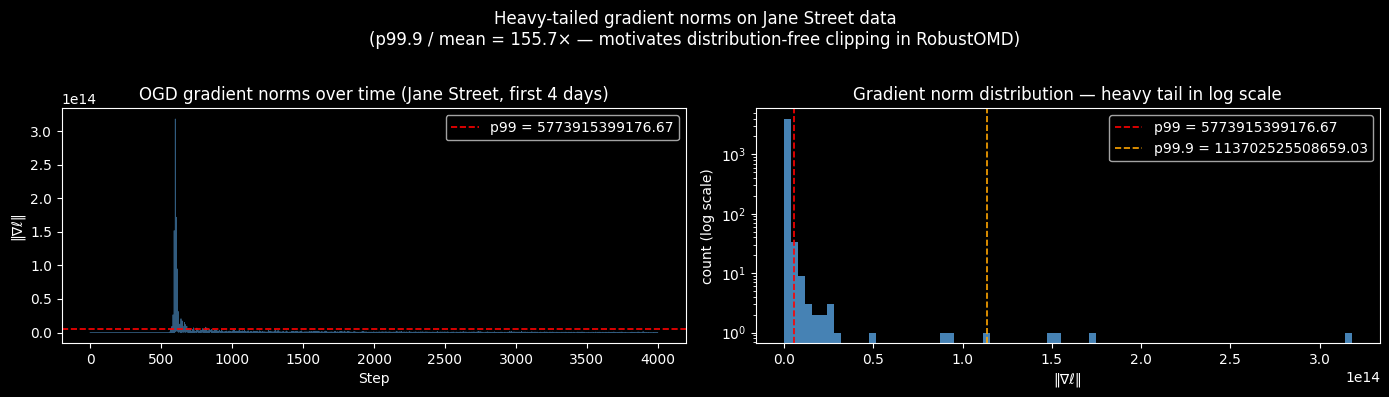

In [7]:
# --- Gradient Norm Distribution: Motivation for Robust Clipping ---
# We stream a small Jane Street slice through standard OGD (with online z-score
# standardization) and record per-step gradient norms. The log-scale histogram
# reveals a heavy tail in the gradient-norm sequence — the direct motivation for
# RobustOMD's distribution-free clipping threshold.

import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from dfsl import JaneStreetDataset, OnlineGradientDescent
from dfsl.preprocessing.normalize import OnlineStandardizer

dataset = JaneStreetDataset(date_range=(0, 4), max_rows=4000)
dim = dataset.dim
learner = OnlineGradientDescent(dim=dim, learning_rate=0.05)
scaler  = OnlineStandardizer(dim=dim)

gradient_norms = []
for x, y, w in dataset:
    x_s  = scaler.fit_transform_step(x)
    pred = learner.predict(x_s)
    g    = 2.0 * w * (pred - y) * x_s
    gradient_norms.append(float(np.linalg.norm(g)))
    learner.update(x_s, y, w)

norms = np.array(gradient_norms)
p99   = float(np.percentile(norms, 99))
p999  = float(np.percentile(norms, 99.9))
ratio = p999 / max(norms.mean(), 1e-9)
logger.info(
    f"Gradient norms — mean: {norms.mean():.3f}  std: {norms.std():.3f}  "
    f"p99: {p99:.3f}  p99.9: {p999:.3f}  max: {norms.max():.3f}  p99.9/mean: {ratio:.1f}×"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(norms, linewidth=0.6, color="steelblue", alpha=0.7)
axes[0].axhline(p99, color="red", linestyle="--", linewidth=1.2, label=f"p99 = {p99:.2f}")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("‖∇ℓ‖")
axes[0].set_title("OGD gradient norms over time (Jane Street, first 4 days)")
axes[0].legend()

axes[1].hist(norms, bins=80, color="steelblue", edgecolor="none", log=True)
axes[1].axvline(p99,  color="red",    linestyle="--", linewidth=1.2, label=f"p99 = {p99:.2f}")
axes[1].axvline(p999, color="orange", linestyle="--", linewidth=1.2, label=f"p99.9 = {p999:.2f}")
axes[1].set_xlabel("‖∇ℓ‖")
axes[1].set_ylabel("count (log scale)")
axes[1].set_title("Gradient norm distribution — heavy tail in log scale")
axes[1].legend()

fig.suptitle(
    f"Heavy-tailed gradient norms on Jane Street data\n"
    f"(p99.9 / mean = {ratio:.1f}× — motivates distribution-free clipping in RobustOMD)"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "gradient_norm_distribution.png", dpi=200)
plt.show()
